# Task 2.1 — Dataset Selection and Setup
**Paper**: *Efficient Online Learning for Large-Scale Sparse Kernel Logistic Regression* (AAAI 2012)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from scipy.spatial.distance import pdist

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
print(f'Random seed set to {RANDOM_SEED}. Libraries loaded.')

Random seed set to 42. Libraries loaded.


## Dataset Justification

I chose the **Breast Cancer Wisconsin (Diagnostic)** dataset for this reproduction. The paper's method addresses binary classification using Kernel Logistic Regression with Gaussian kernels, and this dataset is a natural fit: it is a well-known binary classification problem (malignant vs. benign tumours) with 569 samples and 30 continuous features derived from cell-nucleus measurements. It provides enough samples for the online learning algorithms to exhibit meaningful convergence behaviour while staying small enough for CPU-based kernel computations. Compared to the datasets used in the original paper (mushrooms: 8,124 samples; a9a: 32,561; ijcnn1: 141,691; rcv1: 697,641), this is considerably smaller, so I will not be able to observe the dramatic training-time advantages the paper reports; however, the *relative* sparsity and accuracy trends should still be visible. The dataset is also less noisy than a9a, which should make the conservative updating mechanism more effective at skipping well-classified examples.

In [2]:
data = load_breast_cancer()
X_raw = data.data
y_raw = data.target  # 0 = malignant, 1 = benign

print(f"Number of samples : {X_raw.shape[0]}")
print(f"Number of features: {X_raw.shape[1]}")
print(f"Class distribution : benign={np.sum(y_raw==1)}, malignant={np.sum(y_raw==0)}")

Number of samples : 569
Number of features: 30
Class distribution : benign=357, malignant=212


The dataset has 569 samples with 30 features and a mild class imbalance (roughly 63% benign). This is a reasonable binary classification problem for testing kernel logistic regression.

## Preprocessing

Following the paper's setup, I apply the following preprocessing steps:
1. **Standardise features** to zero mean and unit variance — necessary so that the Gaussian kernel    width $\sigma$ is meaningful across features.
2. **Convert labels** from $\{0, 1\}$ to $\{-1, +1\}$ as required by the KLR formulation in Eq. (2).
3. **Set the kernel width** $\sigma$ to the 5th percentile of pairwise Euclidean distances    (same heuristic used in the paper, Section "Experiments on medium-size data sets").
4. **Split data** 80/20 into training and test sets with a fixed random seed.

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

y = 2 * y_raw - 1  # convert {0,1} -> {-1,+1}

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

print(f"Training set : {X_train.shape[0]} samples")
print(f"Test set     : {X_test.shape[0]} samples")
print(f"Train labels : +1={np.sum(y_train==1)}, -1={np.sum(y_train==-1)}")
print(f"Test  labels : +1={np.sum(y_test==1)}, -1={np.sum(y_test==-1)}")

Training set : 455 samples
Test set     : 114 samples
Train labels : +1=285, -1=170
Test  labels : +1=72, -1=42


In [4]:
pairwise_dists = pdist(X_train, metric='euclidean')
sigma = np.percentile(pairwise_dists, 5)
print(f"Kernel width sigma (5th percentile of pairwise distances): {sigma:.4f}")

Kernel width sigma (5th percentile of pairwise distances): 2.9823


The kernel width $\sigma$ is set to the 5th percentile of pairwise Euclidean distances on the training set, following the exact heuristic described in the paper's experiment section.

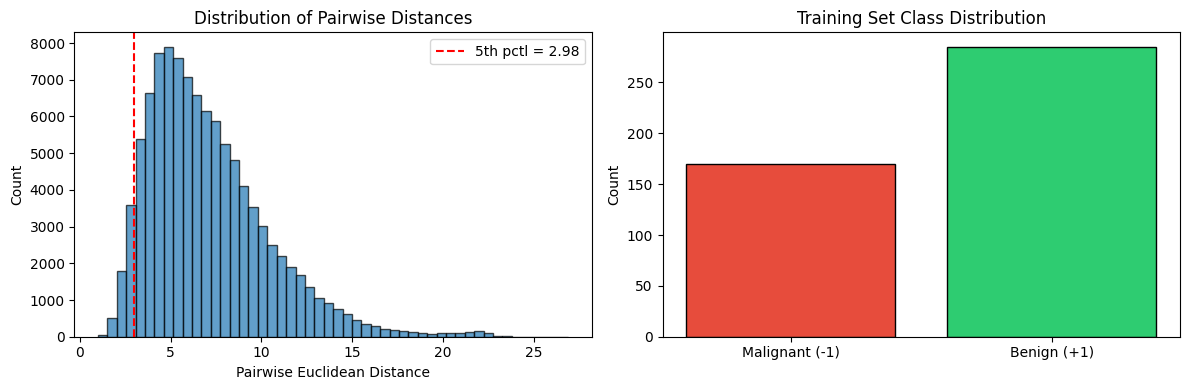

Saved: results/dataset_overview.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(pairwise_dists, bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(sigma, color='red', linestyle='--', label=f'5th pctl = {sigma:.2f}')
axes[0].set_xlabel('Pairwise Euclidean Distance')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Pairwise Distances')
axes[0].legend()

counts = [np.sum(y_train == -1), np.sum(y_train == 1)]
axes[1].bar(['Malignant (-1)', 'Benign (+1)'], counts, color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[1].set_ylabel('Count')
axes[1].set_title('Training Set Class Distribution')

plt.tight_layout()
plt.savefig('results/dataset_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/dataset_overview.png')

The left plot shows the distribution of pairwise Euclidean distances in the standardised training set. The red dashed line marks the 5th percentile used as $\sigma$. The right plot shows the class distribution — slightly imbalanced but not severely so.

In [6]:
np.save('data/X_train.npy', X_train)
np.save('data/X_test.npy', X_test)
np.save('data/y_train.npy', y_train)
np.save('data/y_test.npy', y_test)
np.save('data/sigma.npy', np.array([sigma]))
print('Saved preprocessed arrays to data/ folder.')

Saved preprocessed arrays to data/ folder.
